In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.nn.functional as F
from scipy.signal import butter, filtfilt, stft
from scipy.interpolate import interp1d
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.signal import resample

# from SNN_model import CNNBench, EEG2DCNN
from SNN_data import  load_data, mat_dataset_load, label_balancing, parse_eeg_str

fs = 128

In [5]:
def ds(x):
    x = np.asarray(x)
    n_new = int(x.shape[0] * 128 / 200)
    return resample(x, n_new, axis=0)

In [6]:
# Load data
# restructure seed to distinguish each session
seed = pd.read_csv('./data/EEG_all_sessions_combined.csv')
seed = seed.sort_values(["subject", "video", "channel"]).reset_index(drop=True)

# adding session index to distinguish trials
seed["session_idx"] = seed.groupby(["subject", "video", "channel"]).cumcount()
seed["EEG_clean"] = seed["EEG_clean"].apply(parse_eeg_str) # str to array
# downsample 
seed["EEG_clean"] = seed["EEG_clean"].apply(ds)
# remap label from seed
map_sd = torch.tensor([1, 0, 2, 3])  # index 是原 label，值是新 label
seed["label"] = map_sd[seed['label']]

dreamer = mat_dataset_load('./data/EEG_clean_table.csv')

# Add a columns to distingish the db
dreamer["session_idx"] = -1
dreamer["dataset"] = "dreamer"
seed["dataset"] = "seed"

#combine two dataset
df = pd.concat([dreamer, seed], axis=0, ignore_index=True)
# balance the classes samples
df = label_balancing(df)
# seperate into train/valid/test
train_dataset, valid_dataset, test_dataset = load_data(df)

df_trials (trial-level):
              trial_id  dataset  subject  video  label  session_idx
0   dreamer__10__-1__1  dreamer       10      1      1           -1
1  dreamer__10__-1__10  dreamer       10     10      1           -1
2  dreamer__10__-1__11  dreamer       10     11      1           -1
3  dreamer__10__-1__12  dreamer       10     12      1           -1
4  dreamer__10__-1__13  dreamer       10     13      1           -1
len(df_trials) = 1494
Trial-level counts before balance: [0:493, 1:412, 2:298, 3:291]
Using 291 trials per class (total 1164).
keep_idx min/max: 0 1491
Trial-level counts after balance:
label
0    291
1    291
2    291
3    291
Name: count, dtype: int64
df_bal (segment/channel-level) shape: (16296, 8)
Channel-level label counts after trial balancing:
label_trial
0    4074
1    4074
2    4074
3    4074
Name: count, dtype: int64
=== Group-wise split summary ===
Total segment-samples: 61292
Total trials(groups): 1164
Train segments: 36843 | groups: 698
Valid segme

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEG2DCNN_LSTM_temporal(nn.Module):
    def __init__(self, fs, input_time, in_channels, out_channels,
                 n_classes, eeg_channels, lstm_hidden=64, lstm_layers=1,
                 dropout=0.5):
        super().__init__()
        self.fs = fs
        self.decision_window = input_time
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n_classes = n_classes

        self.window_samples = fs * input_time
        self.kernel_time = 32
        self.stride_time = 16

        # temporal CNN branch
        self.cnn = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels // 2,
                kernel_size=(1, self.kernel_time),
                stride=(1, self.stride_time),
                padding=(0, self.kernel_time // 2),
            ),
            nn.BatchNorm2d(out_channels // 2),
            # nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # spatial branch
        self.spat_branch = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels // 2,
                kernel_size=(eeg_channels, 1),
                stride=(1, self.stride_time),
                padding=(0, 0),
            ),
            nn.BatchNorm2d(out_channels // 2),
            # nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # LSTM over temporal CNN features
        self.lstm = nn.LSTM(
            input_size=out_channels // 2,  # CNN temporal branch channel dim
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=False,
        )

        # fuse spatial summary + LSTM hidden
        self.spat_pool = nn.AdaptiveAvgPool2d((1, 1))  # summarize spatial branch
        fusion_dim = lstm_hidden + out_channels // 2

        self.fc = nn.Sequential(
            nn.Linear(fusion_dim, out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(out_channels, n_classes),
        )

    def forward(self, x):
        # x: (B, 1, T, C)

        # temporal CNN branch
        x_t = self.cnn(x)          # (B, out/2, T', 1)
        x_t_seq = x_t.squeeze(-1)  # (B, out/2, T')
        x_t_seq = x_t_seq.permute(0, 2, 1)  # (B, T', out/2)

        out_seq, (h_n, _) = self.lstm(x_t_seq)
        h_last = h_n[-1]           # (B, lstm_hidden)

        # spatial branch summary
        x_s = self.spat_branch(x)                # (B, out/2, T'', 1)
        x_s = self.spat_pool(x_s)                # (B, out/2, 1, 1)
        x_s = x_s.view(x_s.size(0), -1)          # (B, out/2)

        # fuse + classify
        feat = torch.cat([h_last, x_s], dim=1)   # (B, lstm_hidden + out/2)
        logits = self.fc(feat)
        return logits

In [14]:
df

,subject,video,channel,label,EEG_clean,session_idx,dataset
0,1,1,1,1,"[-0.32212941693096, -1.7593449019415, -1.97413...",-1,dreamer
1,1,1,2,1,"[-1.18755544285539, -1.96786538229069, -1.8054...",-1,dreamer
2,1,1,3,1,"[-2.20935621871928, -1.53590687185864, -1.4312...",-1,dreamer
3,1,1,4,1,"[-1.96054934995803, -1.09346000588319, -0.9064...",-1,dreamer
4,1,1,5,1,"[-1.84782456153978, -0.815967226003276, -0.639...",-1,dreamer
...,...,...,...,...,...,...,...
16291,15,24,12,1,"[1.4108657, 1.6579577, 1.2315115, 1.5451771, 0...",2,seed
16292,15,24,13,3,"[0.3186611, -0.07142412, -0.37058178, 0.039731...",0,seed
16293,15,24,13,1,"[1.3399237, 1.4539698, 0.97752964, 1.3840631, ...",2,seed
16294,15,24,14,3,"[0.0033689076, -0.32549387, -0.5975567, -0.789...",0,seed


In [13]:
# =============================================================================
# Configuration
# =============================================================================

CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 9,        # The simultan
    "eeg_channels": 14,
    "out_channels": 30,       # Number of conv filters / hidden units
    "dropout": 0.25,           # Dropout probability
    "n_classes": 4,
    "lr":  5e-4,
    "num_epochs": 200,
    "batch": 32,
    "save_dir": "./data/checkpoints",
}

# =============================================================================
# Training & evaluation
# =============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch. Returns total loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels, _ in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # data = data.unsqueeze(1) # uncomment this if only 1 in_channel 
        data = data.permute(0,1,3,2) 


        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
        
    acc = correct / total
    return total_loss/total, acc



@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """
    dataloader 要回傳: data, labels, trial_ids
      - data: (B, C_in, H, W)
      - labels: segment label (trial 內都一樣)
      - trial_ids: 同一 trial 用同一個 id (e.g., subject*1000 + video)

    回傳:
      seg_loss, seg_acc, trial_acc
    """
    import numpy as np
    from collections import defaultdict

    model.eval()

    # ---- segment-level 統計 ----
    total_loss = 0.0
    correct = 0
    total = 0

    # ---- trial-level 暫存 (只存每個 segment 的 class prediction 就夠了) ----
    trial_preds = defaultdict(list)   # trial_id -> list of predicted classes
    trial_labels = {}                # trial_id -> true label

    for data, labels, trial_ids in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        data = data.permute(0, 1, 3, 2)  

        logits = model(data)                       # (B, n_classes)
        loss = criterion(logits, labels)

        # ---- segment-level ----
        total_loss += loss.item() * data.size(0)
        pred = logits.argmax(dim=1)                # (B,)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        # ---- trial-level: 收 segment 預測 ----
        preds_np = pred.cpu().numpy()
        trial_ids_np = trial_ids.cpu().numpy()
        labels_np = labels.cpu().numpy()

        for p, tid, y in zip(preds_np, trial_ids_np, labels_np):
            trial_preds[tid].append(int(p))
            trial_labels[tid] = int(y)

    seg_loss = total_loss / total
    seg_acc = correct / total

    # ---- trial-level: majority vote ----
    all_trial_ids = sorted(trial_preds.keys())
    y_true = []
    y_pred = []

    for tid in all_trial_ids:
        preds = np.array(trial_preds[tid], dtype=np.int64)  # (n_seg,)
        counts = np.bincount(preds, minlength=4)            # 4 類
        pred_cls = int(counts.argmax())
        true_cls = trial_labels[tid]

        y_true.append(true_cls)
        y_pred.append(pred_cls)

    y_true = np.array(y_true, dtype=np.int64)
    y_pred = np.array(y_pred, dtype=np.int64)
    trial_acc = (y_true == y_pred).mean()

    return seg_loss, seg_acc, trial_acc


def main(train_losses,valid_losses,train_accs,valid_accs,valid_accs_trial):
    # ==================== Training Configuration =========================

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize model
    print("================ Initalizing Model ==========================")
    print(f"Device: {device}")

    model = EEG2DCNN_LSTM_temporal(fs = 128, n_classes=CONFIG["n_classes"], input_time= 3, in_channels=CONFIG['in_channels'], out_channels = CONFIG['out_channels'],eeg_channels = CONFIG['eeg_channels']).to(device)
    print(model)

    # criterion = snntorch.functional.loss.ce_rate_loss()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # Training loop with best-model checkpointing
    save_dir = Path(CONFIG["save_dir"])
    save_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = save_dir / "best_model.pt"

    

    print("================ Training Execution ==========================")
    best_valid_acc = 0.0
    for epoch in range(CONFIG["num_epochs"]):
        train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc, valid_acc_trial = evaluate(model, valid_loader, criterion, device)
        _, train_acc,_  = evaluate(model, train_loader, criterion, device)


        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)
        valid_accs_trial.append(valid_acc_trial)


        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_train_acc = train_acc
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f} Trial-Based: {valid_acc_trial:.4f}" 
        )

    print(f"\nBest validation accuracy: {best_valid_acc:.4f}")
    print(f"Corresponding train accuracy: {best_train_acc:.4f}")

    # Test with best model
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    _, test_acc, test_acc_trial = evaluate(model, test_loader, criterion, device)
    print(f"Test accuracy: {test_acc:.4f} Trial-Based: {test_acc_trial:.4f}")


if __name__ == "__main__":
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []
    
    valid_accs_trial = []

    
    # DataLoader
    train_loader = DataLoader(dataset= train_dataset, batch_size=CONFIG['batch'], shuffle=True,drop_last=True)
    test_loader = DataLoader(dataset= test_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False)
    valid_loader = DataLoader(dataset= valid_dataset, batch_size=CONFIG['batch'], shuffle=False,drop_last=False) # can't shuffle or the temporarl dynamic will gone
    
    main(train_losses,valid_losses,train_accs,valid_accs,valid_accs_trial)

================ Initalizing Model ==========================
Device: cpu
EEG2DCNN_LSTM_temporal(
  (cnn): Sequential(
    (0): Conv2d(9, 15, kernel_size=(1, 32), stride=(1, 16), padding=(0, 16))
    (1): BatchNorm2d(15, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dropout(p=0.5, inplace=False)
  )
  (spat_branch): Sequential(
    (0): Conv2d(9, 15, kernel_size=(14, 1), stride=(1, 16))
    (1): BatchNorm2d(15, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dropout(p=0.5, inplace=False)
  )
  (lstm): LSTM(15, 64, batch_first=True)
  (spat_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Sequential(
    (0): Linear(in_features=79, out_features=30, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=30, out_features=4, bias=True)
  )
)
================ Training Execution ==========================
Epoch    0 | Train Loss: 1.3233  Acc: 0.3051 | Valid Loss: 1.3388  Acc: 0.3061 Tri

KeyboardInterrupt: 

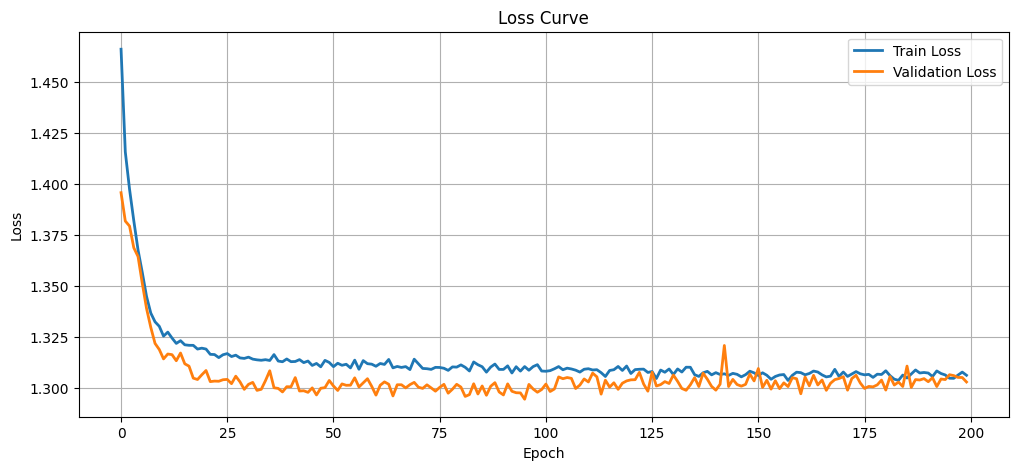

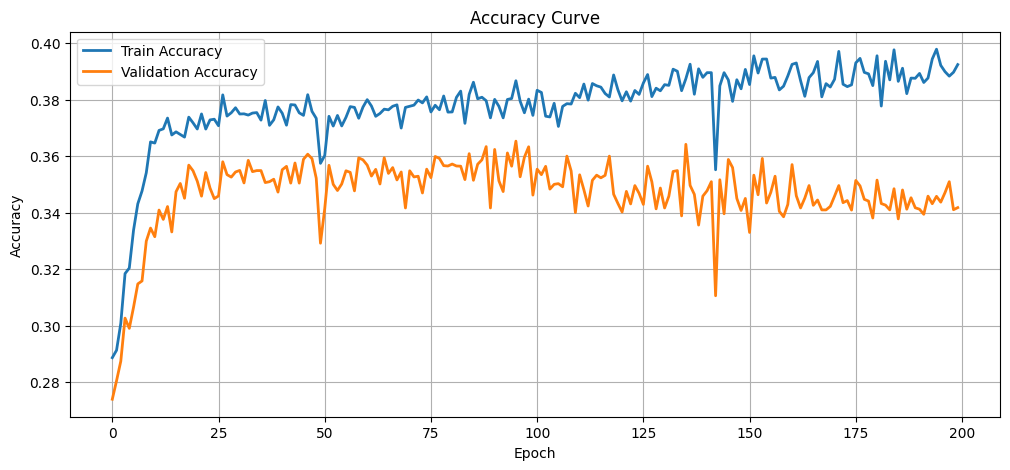

In [ ]:
# plot learning loss & accuracy

plt.figure(figsize=(12,5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(valid_losses, label='Validation Loss', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(valid_accs, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()